# EDA Triatlón: Memoria. Distancia Olímpica vs Ironman. 

Este notebook contiene la memoria principal del proyecto. El objetivo es comparar el rendimiento de atletas élite en dos modalidades de triatlón: distancia Olímpica e Ironman.

La obtención de datos queda documentada en `codigo/API.py`. En esta memoria se cargan los CSVs finales, se homogeneizan las variables necesarias y se analizan las hipótesis mediante visualizaciones.

## Librerías y funciones de visualización

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()
if BASE_DIR.name in ["codigo", "notebook"]:
    PROJECT_DIR = BASE_DIR.parent
else:
    PROJECT_DIR = BASE_DIR

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from codigo.visualizacion import (
    configurar_estilo,
    preparar_df_graficos,
    grafico_muestra_por_modalidad_genero,
    grafico_peso_segmentos_apilado,
    grafico_correlaciones_segmentos,
    grafico_variabilidad_respecto_ganador,
    grafico_brecha_genero_segmentos,
)

configurar_estilo()

DATA_DIR = PROJECT_DIR / "data"
IRONMAN_PATH = DATA_DIR / "ironman_2015_2025" / "ironman_wc_2015_2025_pro_results.csv"
OLIMPICA_PATH = DATA_DIR / "olimpica_2016_2025" / "olimpica_2016_2025_all_results.csv"
TRIATLON_CLEAN_PATH = DATA_DIR / "triatlon_clean.csv"

## Carga de datasets finales por modalidades

Se cargan dos CSVs finales por modalidad:

- Ironman World Championship Kona 2015-2025, filtrado a profesionales (`MPRO` y `FPRO`).
- Distancia Olímpica: Juegos Olímpicos y finales de World Triathlon Championship Series.

In [3]:
ironman = pd.read_csv(IRONMAN_PATH)
olimpica = pd.read_csv(OLIMPICA_PATH)

print("Ironman PRO:", ironman.shape)
print("Olímpica:", olimpica.shape)

Ironman PRO: (954, 50)
Olímpica: (1338, 29)


## Limpieza y homogeneización

Antes de nada, debo realizar una conversión de tiempos a segundos.

Los tiempos de las pruebas vienen en formato texto, por ejemplo `hh:mm:ss` o `mm:ss`.  Para poder comparar segmentos, calcular porcentajes y hacer operaciones numéricas, se transforman todos los tiempos a segundos. Asimismo, la siguiente función también convierte en valores nulos (`NaN`) los registros no válidos, como `DNF`, `DNS`, `DSQ` o `LAP`.

In [ ]:
# convirtiendo tiempos a segundos
def time_to_seconds(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()
    if x in ["", "nan", "None", "DNF", "DNS", "DSQ", "LAP"]:
        return np.nan

    parts = x.split(":")

    try:
        parts = [int(float(p)) for p in parts]
    except ValueError:
        return np.nan

    if len(parts) == 3:
        h, m, s = parts
        return h * 3600 + m * 60 + s

    if len(parts) == 2:
        m, s = parts
        return m * 60 + s

    return np.nan

Para comparar ambas modalidades se crea un dataframe común con columnas equivalentes.

**Importante:** en Ironman se usa `finish_rank_group` como posición, porque representa el ranking dentro del grupo profesional (`MPRO` o `FPRO`). En olímpica, cada carrera ya está separada por género, por lo que `position` funciona como ranking comparable dentro de cada evento.

In [5]:
# Resultados válidos
ironman = ironman[
    (ironman["finisher"] == True) &
    (ironman["dnf"] == False) &
    (ironman["dns"] == False) &
    (ironman["dq"] == False)
].copy()

olimpica["position"] = pd.to_numeric(olimpica["position"], errors="coerce")
olimpica = olimpica.dropna(subset=["position", "total_time"]).copy()

# Homogeneización de género
ironman["gender"] = ironman["gender"].replace({"male": "Male", "female": "Female"})
olimpica["gender"] = olimpica["gender"].replace({"male": "Male", "female": "Female"})

In [6]:
# Ironman limpio
ironman_clean = ironman[[
    "championship_year", "event_name", "athlete", "country_iso3", "gender",
    "finish_rank_group", "finish_time", "finish_seconds",
    "swim_time", "swim_seconds", "t1_time", "t1_seconds",
    "bike_time", "bike_seconds", "t2_time", "t2_seconds",
    "run_time", "run_seconds"
]].copy()

ironman_clean["tipo_distancia"] = "ironman"

ironman_clean = ironman_clean.rename(columns={
    "championship_year": "año",
    "event_name": "evento",
    "athlete": "atleta",
    "country_iso3": "pais",
    "gender": "genero",
    "finish_rank_group": "posicion",
    "finish_time": "tiempo_total",
    "finish_seconds": "segundos_total",
    "swim_time": "tiempo_natacion",
    "swim_seconds": "segundos_natacion",
    "t1_time": "tiempo_t1",
    "t1_seconds": "segundos_t1",
    "bike_time": "tiempo_bicicleta",
    "bike_seconds": "segundos_bicicleta",
    "t2_time": "tiempo_t2",
    "t2_seconds": "segundos_t2",
    "run_time": "tiempo_carrera",
    "run_seconds": "segundos_carrera",
})

# Olímpica limpia
olimpica_clean = olimpica[[
    "championship_year", "event_title", "athlete_full_name", "athlete_noc",
    "gender", "position", "total_time", "swim", "t1", "bike", "t2", "run", "dataset"
]].copy()

olimpica_clean["tipo_distancia"] = "olimpica"

olimpica_clean = olimpica_clean.rename(columns={
    "championship_year": "año",
    "event_title": "evento",
    "athlete_full_name": "atleta",
    "athlete_noc": "pais",
    "gender": "genero",
    "position": "posicion",
    "total_time": "tiempo_total",
    "swim": "tiempo_natacion",
    "t1": "tiempo_t1",
    "bike": "tiempo_bicicleta",
    "t2": "tiempo_t2",
    "run": "tiempo_carrera",
    "dataset": "tipo_evento",
})

for col in ["tiempo_total", "tiempo_natacion", "tiempo_t1", "tiempo_bicicleta", "tiempo_t2", "tiempo_carrera"]:
    nueva_col = col.replace("tiempo_", "segundos_")
    olimpica_clean[nueva_col] = olimpica_clean[col].apply(time_to_seconds)

In [7]:
columnas_comunes = [
    "tipo_distancia", "año", "evento", "atleta", "pais", "genero", "posicion",
    "tiempo_total", "segundos_total",
    "tiempo_natacion", "segundos_natacion",
    "tiempo_t1", "segundos_t1",
    "tiempo_bicicleta", "segundos_bicicleta",
    "tiempo_t2", "segundos_t2",
    "tiempo_carrera", "segundos_carrera",
]

triatlon_clean = pd.concat([
    ironman_clean[columnas_comunes],
    olimpica_clean[columnas_comunes]
], ignore_index=True)

# Elimina tiempos no reales, por ejemplo, segmentos a 00:00:00. Para comparar ambas modalidades con el mismo criterio competitivo, se limita el analisis 
# a las primeras 40 posiciones de cada carrera/genero.

posicion_maxima = 40
triatlon_clean = preparar_df_graficos(triatlon_clean, posicion_max=posicion_maxima)

triatlon_clean.to_csv(TRIATLON_CLEAN_PATH, index=False)

print("Dataset limpio:", triatlon_clean.shape)
triatlon_clean.head()

Dataset limpio: (1634, 24)


,tipo_distancia,año,evento,atleta,pais,genero,posicion,tiempo_total,segundos_total,tiempo_natacion,...,segundos_bicicleta,tiempo_t2,segundos_t2,tiempo_carrera,segundos_carrera,pct_natacion,pct_bicicleta,pct_carrera,pct_transiciones,top_10
0,ironman,2015,2015 IRONMAN World Championship,Jan Frodeno,DEU,Male,1.0,8:14:40,29680,0:50:50,...,16047,NaN,131,2:52:21,10341,10.276280,54.066712,34.841644,0.815364,True
1,ironman,2015,2015 IRONMAN World Championship,Andreas Raelert,DEU,Male,2.0,8:17:43,29863,0:52:24,...,16252,NaN,149,2:50:02,10202,10.528078,54.421860,34.162676,0.887386,True
2,ironman,2015,2015 IRONMAN World Championship,Timothy O'Donnell,USA,Male,3.0,8:18:50,29930,0:52:24,...,15973,NaN,146,2:55:46,10546,10.504511,53.367858,35.235550,0.892082,True
3,ironman,2015,2015 IRONMAN World Championship,Andy Potts,USA,Male,4.0,8:21:25,30085,0:50:56,...,16361,NaN,140,2:53:45,10425,10.157886,54.382583,34.651820,0.807711,True
4,ironman,2015,2015 IRONMAN World Championship,Tyler Butterfield,BMU,Male,5.0,8:23:09,30189,0:52:33,...,16175,NaN,161,2:56:19,10579,10.444202,53.579118,35.042565,0.934115,True


## Análisis descriptivo inicial

Antes de contrastar hipótesis, se revisa la composición del dataset final por modalidad y género. 
Para que la comparacion entre Ironman y Olimpica sea mas equilibrada, el análisis se limita a atletas con posición menor o igual a 40 dentro de cada carrera y género.


In [8]:
triatlon_clean.groupby(["tipo_distancia", "genero"]).size()

tipo_distancia  genero
ironman         Female    326
                Male      377
olimpica        Female    457
                Male      474
dtype: int64

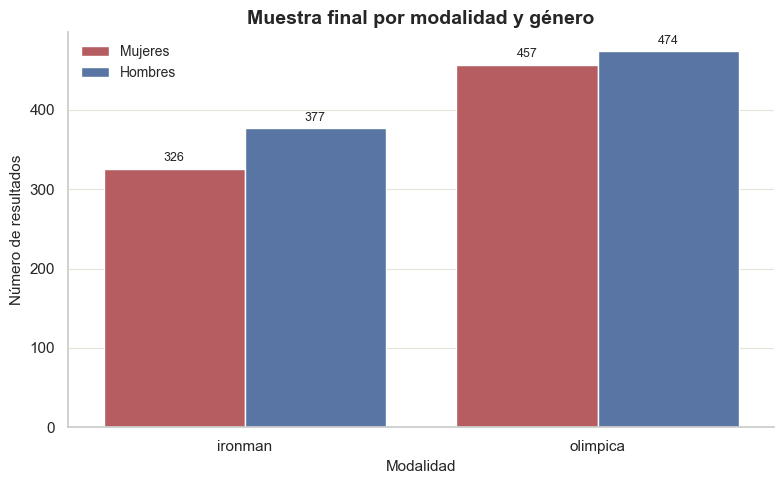

In [9]:
grafico_muestra_por_modalidad_genero(triatlon_clean)
plt.show()

## Hipótesis 1

**"El segmento de bicicleta tiene mayor peso sobre el tiempo total en Ironman que en distancia olímpica".**

Para contrastar esta hipótesis se calcula qué porcentaje del tiempo total representa cada segmento: natación, bicicleta, carrera y transiciones.

El gráfico más adecuado es una barra apilada, porque permite comparar la distribución del tiempo dentro de cada modalidad sin usar tiempos absolutos. Esto es importante porque Ironman y distancia olímpica tienen duraciones muy diferentes.


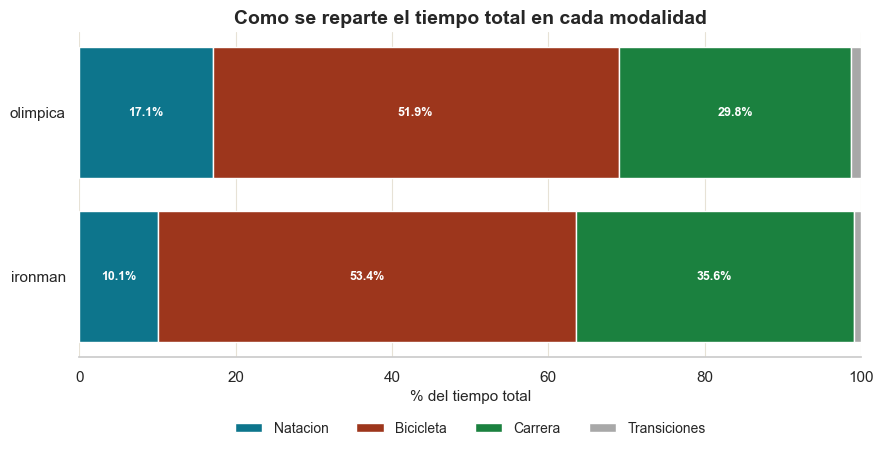

,Natacion,Bicicleta,Carrera,Transiciones
tipo_distancia,,,,
ironman,10.108155,53.353981,35.592651,0.945199
olimpica,17.073902,51.889659,29.783696,1.274312


In [10]:
ax, media_segmentos = grafico_peso_segmentos_apilado(triatlon_clean)
plt.show()
media_segmentos

##### Interpretación

En ambas modalidades, la bicicleta es el segmento con mayor peso sobre el tiempo total. En Ironman representa aproximadamente el **53.4%** del tiempo total, mientras que en distancia olímpica supone alrededor del **51.9%**.

Por tanto, la hipótesis se confirma, aunque la diferencia no es muy grande. La bicicleta pesa ligeramente más en Ironman, algo coherente con la naturaleza de esta distancia: el segmento ciclista es mucho más largo y condiciona más la estrategia global de carrera.

## Hipótesis 2

**"La carrera a pie está más relacionada con la posición final en distancia Olímpica que en Ironman".**

Para comprobarlo se calcula la correlación de Spearman entre el ranking del parcial de carrera y la posición final. Se utiliza Spearman porque interesa medir si existe una relación ordenada entre dos rankings: correr mejor y terminar mejor clasificado.

Además, se compara la fuerza de esta relación con otros segmentos para entender si la carrera es realmente el parcial más determinante.


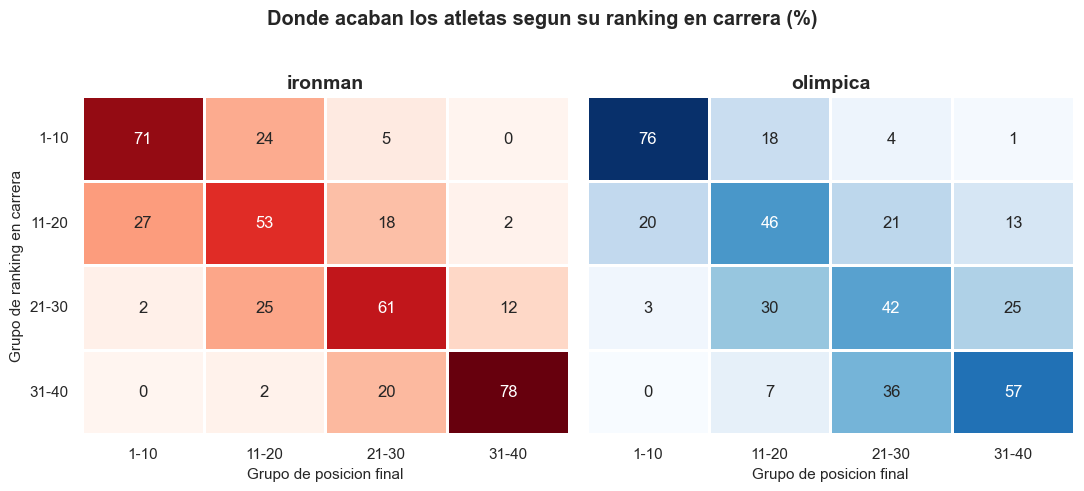

,Natacion,Bicicleta,Carrera
tipo_distancia,,,
ironman,0.276961,0.722476,0.844253
olimpica,0.440091,0.607100,0.774896


In [11]:
ax, corr_media, corr_eventos = grafico_correlaciones_segmentos(triatlon_clean)
plt.show()
corr_media

### Interpretación

La correlación de Spearman muestra que la carrera a pie está muy relacionada con la posición final en ambas modalidades. Sin embargo, el resultado no confirma la hipótesis inicial: la relación es mayor en Ironman que en distancia olímpica.

En Ironman, la correlación media entre carrera y posición final es aproximadamente **0.844**, mientras que en distancia olímpica es aproximadamente **0.775**. Esto indica que, dentro del top 40, quienes corren mejor tienden a terminar mejor clasificados, especialmente en Ironman.

Por tanto, la hipótesis no se confirma. El resultado observado es el contrario al planteado inicialmente.

## Hipótesis 3

**"La variabilidad de tiempos es mayor en Ironman que en distancia olímpica".**

Para analizar esta hipótesis se calcula la diferencia porcentual de cada atleta respecto al ganador de su mismo evento y género.

Esta métrica permite comparar modalidades de distinta duración de forma justa: no se comparan segundos absolutos, sino cuánto se aleja cada atleta del mejor tiempo de su carrera.


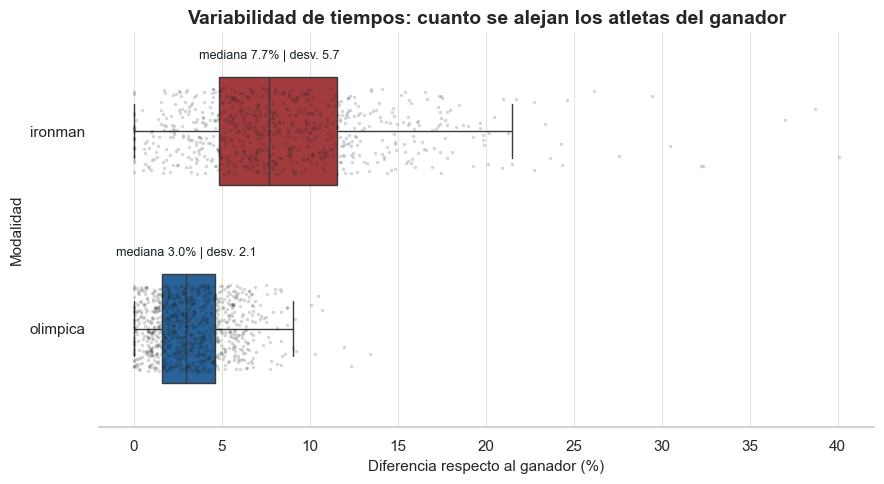

,count,mean,std,min,25%,50%,75%,max
tipo_distancia,,,,,,,,
ironman,703.0,8.614528,5.664373,0.0,4.809496,7.674195,11.538967,40.065794
olimpica,931.0,3.238614,2.124722,0.0,1.607452,2.958107,4.619767,13.393887


In [12]:
ax, triatlon_variabilidad = grafico_variabilidad_respecto_ganador(triatlon_clean)
plt.show()

triatlon_variabilidad.groupby("tipo_distancia")["diferencia_ganador_pct"].describe()

### Interpretación

En Ironman, la mediana de diferencia respecto al ganador es aproximadamente **7.7%**, mientras que en distancia olímpica es aproximadamente **3.0%**. Esto indica que, en una posición central de la distribución, los atletas de Ironman se alejan más del ganador que los atletas de distancia olímpica. De hecho, la dispersion es mayor en Ironman, tal y como muestra la desviación estándar : **5.7%** en Ironman frente a **2.1%** en Olímpica.

Por tanto, la hipótesis se confirma: en Ironman hay más variabilidad de tiempos que en distancia Olímpica. Tiene sentido porque es una prueba mucho más larga, donde la fatiga, la nutrición, el ritmo y la estrategia pueden generar diferencias acumuladas mayores.


## Hipótesis 4

**"La diferencia porcentual de rendimiento entre hombres y mujeres varía según la modalidad y el segmento."**

Para comparar hombres y mujeres de forma justa, se calcula la diferencia porcentual entre la mediana femenina y la mediana masculina dentro de cada evento, año y modalidad.

Después se analiza esa brecha por segmento: natación, bicicleta y carrera. Así se evita sacar conclusiones solo a partir del tiempo total y se puede ver si la diferencia cambia según la parte de la prueba.


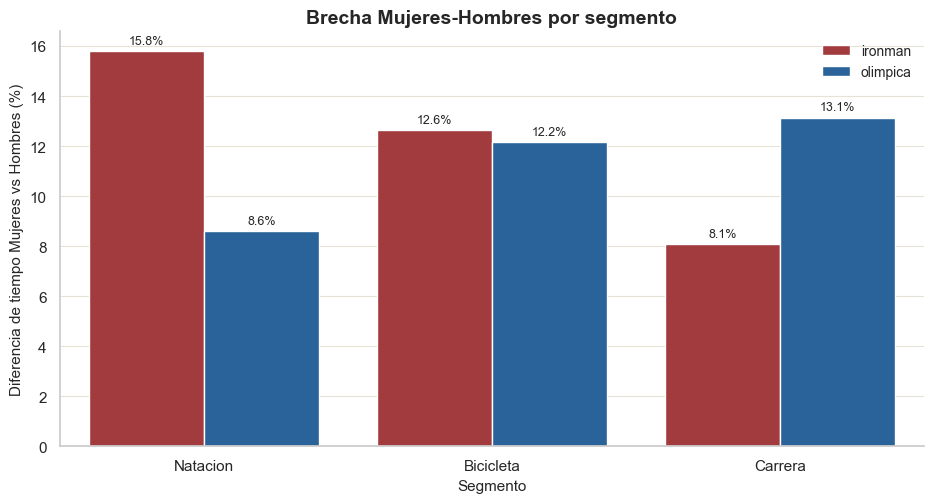

genero,tipo_distancia,anio,evento,Female,Male,diferencia_genero_pct,segmento
0,ironman,2015,2015 IRONMAN World Championship,3599.0,3155.5,14.054825,Natacion
1,ironman,2016,2016 IRONMAN World Championship,3537.0,2972.5,18.990749,Natacion
2,ironman,2017,2017 IRONMAN World Championship,3477.0,2941.5,18.204997,Natacion
3,ironman,2018,2018 IRONMAN World Championship,3503.5,3041.5,15.189873,Natacion
4,ironman,2019,2019 IRONMAN World Championship,3546.0,3117.5,13.744988,Natacion
5,ironman,2021,2021 IRONMAN World Championship,3562.5,3109.0,14.586684,Natacion
6,olimpica,2016,2016 ITU World Triathlon Grand Final Cozumel,1171.5,1037.5,12.915663,Natacion
7,olimpica,2016,Rio de Janeiro 2016 Olympic Games,1152.5,1054.5,9.293504,Natacion
8,olimpica,2017,2017 ITU World Triathlon Grand Final Rotterdam,1194.0,1142.5,4.507659,Natacion
9,olimpica,2018,2018 ITU World Triathlon Grand Final Gold Coast,1184.5,1146.5,3.314435,Natacion


In [14]:
ax, brecha_genero_segmentos = grafico_brecha_genero_segmentos(triatlon_clean)
plt.show()
brecha_genero_segmentos.head(10)


### Interpretación

La brecha porcentual entre mujeres y hombres no es igual en todos los segmentos ni en ambas modalidades.

En Ironman, la mayor diferencia aparece en natación, con una brecha media aproximada del **15.8%**. En distancia olímpica, la mayor diferencia aparece en carrera, con una brecha aproximada del **13.1%**. En bicicleta, la diferencia es muy parecida entre modalidades: **12.6%** en Ironman y **12.2%** en distancia olímpica.

Por tanto, la hipótesis se confirma: la diferencia de rendimiento entre hombres y mujeres varía según la modalidad y el segmento analizado.

## Conclusiones finales

El análisis muestra que la distancia modifica la forma en la que se reparte el rendimiento en triatlón.

La bicicleta es el segmento con mayor peso en ambas modalidades, aunque pesa ligeramente más en Ironman. La carrera a pie también es clave, pero la hipótesis inicial no se cumple, ya que la relación entre carrera y posición final es incluso mayor en Ironman que en distancia olímpica.

Además, Ironman presenta una variabilidad de tiempos mucho mayor respecto al ganador, lo que indica que en pruebas largas las diferencias entre atletas se amplifican. Por último, la comparación por género muestra que la brecha Mujeres-Hombres depende del segmento: en Ironman destaca la natación, mientras que en distancia olímpica destaca la carrera.

En conjunto, el proyecto confirma que no basta con comparar tiempos absolutos entre modalidades. Para entender el rendimiento en triatlón es necesario trabajar con porcentajes, rankings relativos y diferencias respecto al ganador.